In [ ]:
import pandas as pd

# Load in datasets (issues with Yoon 2019)
pre = "https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/"
datasets = ["boyce2024_interaction/", "eliav2023_semantic/", "hawkins2019_continual/", "hawkins2020_characterizing_cued/", "hawkins2021_respect/",
            "hawkins2023_frompartners/", "leung2024_scaffolding/",
            "mankewitz2025_function/"]
end = ["messages.csv", "trials.csv"]
lst_datasets = [[pre + dataset + end[0], pre + dataset + end[1]] for dataset in datasets]
lst_dfs = []

# Pre-process datasets
for dataset in lst_datasets:
  print(dataset[0], dataset[1])
  message_df = pd.read_csv(dataset[0])
  trials_df = pd.read_csv(dataset[1])

  result = pd.merge(message_df, trials_df, on="trial_id", how="left")
  cleaned_result = result[
      (result["role"] == "describer") &
      (result["text"].notna()) &
      (result["stage_num"] == 1)][["text", "rep_num"]].reset_index()
  lst_dfs.append(cleaned_result)

# Load in Hawkins 2020 Uncued
hawkins_uncued = pd.read_csv("https://raw.githubusercontent.com/refbank/refbank-import/main/import/hawkins2020_characterizing_uncued/segmented_data.csv")
hawkins_cleaned = hawkins_uncued[
      (hawkins_uncued["role"] == "describer") &
      (hawkins_uncued["text"].notna()) &
      (hawkins_uncued["stage_num"] == 1)][["text", "rep_num"]].reset_index()
lst_dfs.append(hawkins_cleaned)



https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/boyce2024_interaction/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/boyce2024_interaction/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/eliav2023_semantic/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/eliav2023_semantic/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2019_continual/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2019_continual/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2020_characterizing_cued/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2020_characterizing_cued/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2021_

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")


In [ ]:
import numpy
indef = ["a", "an"]
the = ["the"]
this_that = ["this", "that"]
these_those = ["these", "those"]

# Function that builds dictionary containing each word type, its color, its label, and NaN for 'Results'

def build_empty_dic(num_rounds):
  first_word_dic = {}
  categories = {'indef': "'a'/'an'", "the": "'the'", "this_that": "'this'/'that'", "these_those": "'these'/'those'", "poss_pro": "possessive pronoun", "pers_pro": "personal pronoun", "other_pro": "other pronoun", "bare_noun": "bare noun", "num": "number", "adj": "adjective", "other": "other"}
  colors = {'indef': "red", "the": "orange", "this_that": "yellow", "these_those": "green", "poss_pro": "blue", "pers_pro": "purple", "other_pro": "black", "bare_noun": "gray", "num": "lightgreen", "adj": "pink", "other": "lightblue"}
  for cat in categories:
    first_word_dic[cat] = {}
  for key in first_word_dic:
    first_word_dic[key]["Label"] = categories[key]
    first_word_dic[key]["Color"] = colors[key]
    first_word_dic[key]["Total"] = {num: (numpy.nan) for num in range(1, num_rounds + 1)}
    first_word_dic[key]["Percentage"] = {num: (numpy.nan) for num in range(1, num_rounds + 1)}

  return(first_word_dic)

In [ ]:
# Goes through each noun chunk and sorts the words into cateogries in "overall_df"

num_rounds = 6
total_df = pd.DataFrame(columns=["speech_type"] + [num for num in range(1, num_rounds + 1)])
percentage_df = pd.DataFrame(columns=["speech_type"] + [num for num in range(1, num_rounds + 1)])

other_lst = []


for df in lst_dfs: # Goes through each dataset
  first_word_dic = build_empty_dic(num_rounds)
  for i in range(1, len(df.rep_num.unique()) + 1): # Replaces NaN values in "Results" for each cateogry in first_word_dic
    for key in first_word_dic:
      first_word_dic[key]["Total"][i] = 0
      first_word_dic[key]["Percentage"][i] = 0

  for i in range(1, len(df.rep_num.unique()) + 1): # Goes through each round in the dataset
    print(i) # Keeps track of computer process while runing
    texts = df[df["rep_num"] == i]["text"].dropna().tolist()
    docs = list(nlp.pipe((text.lower() for text in texts), batch_size=1000))
    round_words = 0
    for doc in docs:
      for np in doc.noun_chunks: # Goes trhough each noun chunk
        round_words += 1
        first_word = np[0].text.lower()
        word_pos = np[0].pos_
        word_tag = np[0].tag_
        if word_pos == "SYM" or word_pos == "PUNCT" or word_pos == "SPACE" or word_pos == "EOL": # Remove symbols, punctuations, spaces, and EOL from dataset
          round_words -= 1
        else:
          if first_word in indef:
            first_word_dic["indef"]["Total"][i] += 1
          elif first_word in the:
            first_word_dic["the"]["Total"][i] += 1
          elif first_word in this_that:
            first_word_dic["this_that"]["Total"][i] += 1
          elif first_word in these_those:
            first_word_dic["these_those"]["Total"][i] += 1
          else:

            if word_pos == "PRON":
              if word_tag == "PRP$":
                first_word_dic["poss_pro"]["Total"][i] += 1
              elif word_tag == "PRP":
                first_word_dic["pers_pro"]["Total"][i] += 1
              else:
                first_word_dic["other_pro"]["Total"][i] += 1
            elif word_pos == "NOUN" or word_pos == "PROPN":
                first_word_dic["bare_noun"]["Total"][i] += 1
            elif first_word.isnumeric() or word_tag == "CD":
                first_word_dic["num"]["Total"][i] += 1
            elif word_pos == "ADJ":
                first_word_dic["adj"]["Total"][i] += 1
            else:
                first_word_dic["other"]["Total"][i] += 1
                other_lst.append(str(np) + ", pos: " + str(word_pos) + ", tag: " + str(word_tag)) # Keeps track of which words get put in "Other"

    for key in first_word_dic: # Calculate word percentage of each category
      first_word_dic[key]["Percentage"][i] = first_word_dic[key]["Total"][i] / round_words

  for key in first_word_dic: # Turns dictionary into a dataframe with results
    total_row = [key] + list(first_word_dic[key]["Total"].values())
    total_df.loc[len(total_df)] = total_row
    percentage_row = [key] + list(first_word_dic[key]["Percentage"].values())
    percentage_df.loc[len(percentage_df)] = percentage_row


1
2
3
4
5
6
1
2
3
4
5
1
2
3
4
5
6
1
2
3
4
5
6
1
2
3
4
1
2
3
4
1
2
3
4
1
2
3
4
1
2
3
4
5
6


In [ ]:
# Save dataframe
total_df.to_csv("overall_def_total_no_puncsym_v2.csv", index=False)
percentage_df.to_csv("overall_def_perc_no_puncsym_v2.csv", index=False)


In [ ]:
# Create mean dataframe
mean_df = total_df.groupby("speech_type").mean()
mean_df.to_csv("mean_def_perc.csv", index=False)

[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]
[1. 2. 3. 4. 5. 6.]


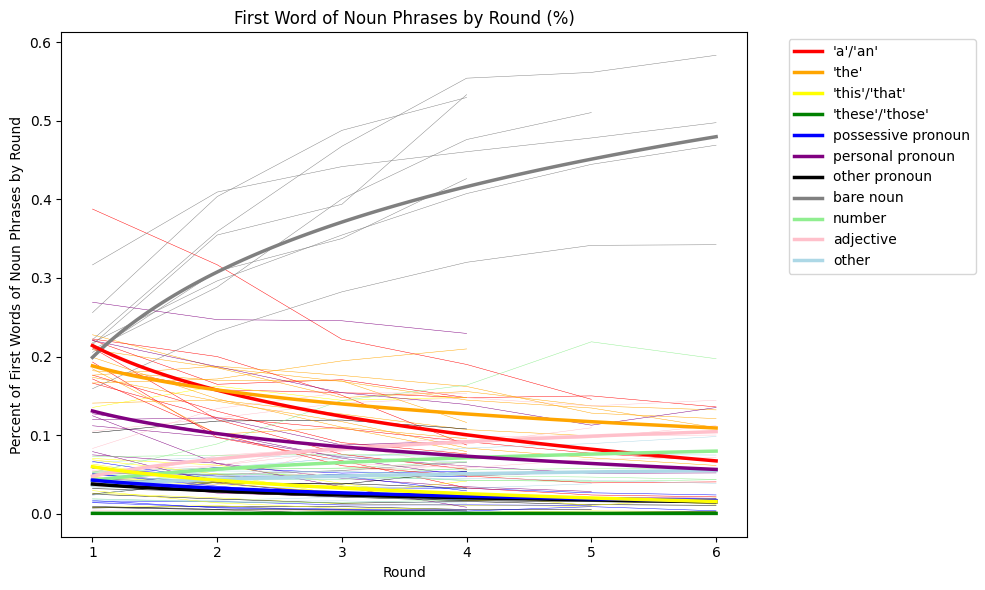

In [ ]:
# Plot spaghetti_plot

import matplotlib.pyplot as plt

fig_02, ax2 = plt.subplots(figsize=(10,6))
for idx in range(len(percentage_df)):
  ax2.plot(percentage_df.columns[1:],
           percentage_df.iloc[idx, 1:],
           color = first_word_dic[percentage_df.iloc[idx, 0]]["Color"],
           linewidth=0.33,
           label = first_word_dic[percentage_df.iloc[idx, 0]]["Label"])
mean_df = percentage_df.groupby("speech_type").mean()

for idx in range(len(mean_df)):
  x_data = numpy.array(mean_df.columns, dtype=float)
  y_data = numpy.array(mean_df.iloc[idx,:], dtype=float)
  coefficients = numpy.polyfit(numpy.log(x_data), y_data, 1)
  slope = coefficients[0]
  y_int = coefficients[1]
  x_dp = numpy.linspace(min(x_data), max(x_data), 100)
  print(x_data)
  y_dp = numpy.polyval(coefficients, numpy.log(x_dp))
  ax2.plot(x_dp,
           y_dp,
           color = first_word_dic[mean_df.index[idx]]["Color"],
           linewidth=2.5,
           label = first_word_dic[mean_df.index[idx]]["Label"]
           )
handles, labels = ax2.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax2.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_title("First Word of Noun Phrases by Round (%)")
ax2.set_xlabel("Round")
ax2.set_ylabel("Percent of First Words of Noun Phrases by Round")
fig_02.tight_layout()
fig_02.show()
fig_02.savefig("6 Round Full Spaghetti Plot of First Word of Noun Phrases (with Proper Nouns) (%).png")